<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
# <font color='blue'>Fundamentos de Linguagem Python - Do Básico a Aplicações de IA</font>
# <font color='blue'>Mini-Projeto 1</font>
# <font color='blue'>Análise de Vendas Para Loja de E-commerce com NumPy, Pandas e Matplotlib</font>

## 1. Definição do Problema de Negócio

**1.1. O Problema de Negócio**

Nossa loja de e-commerce está em fase de crescimento, registrando um volume cada vez maior de transações diárias. No entanto, essa grande quantidade de dados de vendas, em seu estado bruto, é como um baú de tesouro trancado: sabemos que há valor ali, mas não conseguimos acessá-lo.

Atualmente, muitas de nossas decisões estratégicas são baseadas em intuição e observações parciais, o que nos leva a enfrentar os seguintes desafios:

- Gestão de Estoque Ineficiente: Não temos clareza sobre quais produtos são nossos "campeões de venda" e quais estão parados nas prateleiras. Isso resulta em excesso de estoque de itens de baixa procura e falta de produtos de alta demanda.

- Marketing com Baixo Retorno: Nossas campanhas de marketing são genéricas, pois não sabemos quais categorias de produtos atraem mais os clientes ou em quais regiões geográficas nosso público está mais concentrado.

- Perda de Oportunidades Sazonais: Não conseguimos identificar padrões ou tendências de vendas ao longo dos meses. Isso nos impede de planejar promoções estratégicas para períodos de alta ou de criar ações para impulsionar as vendas em meses de baixa.

- Expansão sem Direção: Temos o desejo de expandir, mas não sabemos quais mercados regionais são mais promissores ou onde nossos esforços logísticos deveriam ser focados.

O problema central é a falta de visibilidade clara sobre a performance do negócio, o que nos impede de tomar decisões rápidas, inteligentes e baseadas em evidências.

**1.2. Objetivos do Projeto**

Este projeto de análise de dados visa transformar nossos dados brutos de vendas em insights acionáveis. O objetivo é responder a quatro perguntas de negócio fundamentais:

- O que vender? Identificar os produtos de maior sucesso para otimizar nosso portfólio e estoque.
<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
- Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.

- Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.

- Para onde expandir? Mapear a distribuição geográfica de nossas vendas para descobrir nossos mercados mais fortes.

**1.3. Solução Proposta**

A solução consiste em consolidar, limpar e analisar o histórico de dados de vendas da nossa plataforma. Utilizando ferramentas de análise de dados (como Python com Pandas, NumPy e Matplotlib), vamos processar essas informações e criar um relatório visual que apresente as descobertas de forma clara e intuitiva para as equipes de gestão, marketing e operações.

**1.4. Resultados Esperados e Benefícios de Negócio**

Ao final deste projeto, esperamos alcançar os seguintes resultados:

- Otimização de Estoque: Com a lista dos produtos mais e menos vendidos, poderemos ajustar nossas compras, reduzir custos com armazenamento e evitar a perda de vendas por falta de produto.

- Marketing Direcionado e Eficaz: Sabendo quais categorias e regiões são mais lucrativas, a equipe de marketing poderá criar campanhas segmentadas, aumentando o retorno sobre o investimento (ROI).

- Planejamento Estratégico: A visualização das tendências mensais permitirá um melhor planejamento financeiro, promocional e de recursos, antecipando períodos de alta e baixa demanda.

- Decisões Baseadas em Dados: Substituiremos a intuição por dados concretos, criando uma cultura orientada a dados que impulsionará o crescimento sustentável do negócio.

## 2. Importação das Bibliotecas

In [1]:
!pip install -q -U watermark

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from datetime import datetime, timedelta

%matplotlib inline

In [16]:
%reload_ext watermark
%watermark -a "Patrick Coelho & DSA"

Author: Patrick Coelho & DSA



In [17]:
%watermark --iversions

json      : 2.0.9
matplotlib: 3.10.3
numpy     : 2.2.5
pandas    : 2.2.3
seaborn   : 0.13.2



In [18]:
# Para instalar uma versão específica de um pacote, podemos fazer assim (por exemplo):
#!pip install -q pandas==2.3.1
# No momento em que testei a célula estava usando o collab que não é
# compatível com a versão pandas. %% [markdown]

## 3. Função Para Geração de Dados Fictícios

In [19]:
# Definindo função para gerar os dados fictícios:

def dados_ficticios(num_linhas = 800):

    """
    Função para gerar dados fictícios de vendas de uma loja de e-commerce.
    """
    # Informando usuário
    print(f"\n Processando e gerando {num_linhas} registros de dados...\n")

    # Produtos do catálogo
    produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco': 600.00},
        'Webcam 1080p': {'categoria': 'Acessórios', 'preco': 350.00},
        'Impressora Laser': {'categoria': 'Impressão', 'preco': 1500.00},
        'Tablet 10.1"': {'categoria': 'Eletrônicos', 'preco': 2200.00}
    }

    # Criando lista com os produtos
    products_list = list(produtos.keys())

    # Definindo cidades para vendas (capitais e UF)
    cidade_uf = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE', 'Goiânia': 'GO',
        'Brasília': 'DF', 'Manaus': 'AM', 'Belém': 'PA', 'Florianópolis': 'SC', 'Recife': 'PE',
    }

    # Criando lista com as cidades
    cidades_list = list(cidade_uf.keys())

    data_inicial = datetime(2025, 1, 1)

    # Criando lista vazia com o registro de vendas
    vendas = []

    # Loop for para gerar os registros

    for i in range(num_linhas):

        nome_produto = random.choice(products_list)

        cidade = random.choice(cidades_list)

        data_pedido = data_inicial + timedelta(days = int(i/5), hours = random.randint(0, 23))

        quantidade = random.randint(1, 10)

        if nome_produto in ['Cadeira Gamer', 'Monitor Ultrawide']:
            preco_unitario = produtos[nome_produto]['preco'] * np.random.uniform(0.9, 1.0)
        else:
            preco_unitario = produtos[nome_produto]['preco']

        vendas.append({
            'id': 100 + i,
            'id_client': random.randint(1, 100),
            'Data_Pedido': data_pedido,
            'Nome_Produto': nome_produto,
            'Categoria': produtos[nome_produto]['categoria'],
            'Preco_Unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'Cidade': cidade,
            'Estado': cidade_uf[cidade]
        })

    print("Geração de dados concluída!.\n")

    return pd.DataFrame(vendas)

## 4. Gerar, Carregar e Explorar os Dados

In [20]:
# Gera os dados chamando a função da célula anterior
df_vendas = dados_ficticios(1000)


 Processando e gerando 1000 registros de dados...

Geração de dados concluída!.



In [21]:
type(df_vendas)

pandas.core.frame.DataFrame

In [22]:
# Shape -> Apresenta a qtd. de linhas e colunas do df no formato (L, C)
df_vendas.shape

(1000, 9)

In [23]:
# Head -> Exibe as 5 primeiras linhas do DataFrame (Iniciando na linha 0)
df_vendas.head()

,id,id_client,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,Cidade,Estado
0,100,1,2025-01-01 14:00:00,Monitor Ultrawide,Eletrônicos,2594.62,2,Fortaleza,CE
1,101,36,2025-01-01 10:00:00,Teclado Mecânico,Acessórios,550.00,7,Salvador,BA
2,102,92,2025-01-01 12:00:00,Placa de Vídeo,Hardware,4500.00,3,Porto Alegre,RS
3,103,34,2025-01-01 07:00:00,Headset 7.1,Acessórios,800.00,6,Belém,PA
4,104,12,2025-01-01 13:00:00,Laptop Gamer,Eletrônicos,7500.00,2,Manaus,AM


In [24]:
# Tail -> Exibe as 5 últimas linhas do DataFrame
df_vendas.tail()

,id,id_client,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,Cidade,Estado
995,1095,8,2025-07-19 06:00:00,Impressora Laser,Impressão,1500.00,9,Goiânia,GO
996,1096,98,2025-07-19 05:00:00,Monitor Ultrawide,Eletrônicos,2795.83,7,Recife,PE
997,1097,69,2025-07-19 01:00:00,"Tablet 10.1""",Eletrônicos,2200.00,7,Rio de Janeiro,RJ
998,1098,77,2025-07-19 06:00:00,Mouse Vertical,Acessórios,250.00,1,Florianópolis,SC
999,1099,80,2025-07-19 18:00:00,"Tablet 10.1""",Eletrônicos,2200.00,1,Rio de Janeiro,RJ


In [25]:
# Info -> Exibe informações gerais sobre o DataFrame (tipos de dados, valores não nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              1000 non-null   int64         
 1   id_client       1000 non-null   int64         
 2   Data_Pedido     1000 non-null   datetime64[ns]
 3   Nome_Produto    1000 non-null   object        
 4   Categoria       1000 non-null   object        
 5   Preco_Unitario  1000 non-null   float64       
 6   Quantidade      1000 non-null   int64         
 7   Cidade          1000 non-null   object        
 8   Estado          1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 70.4+ KB


In [26]:
# Describe -> Resumo estatístico do df, (Média, mediana, mínima, máximo, quartis e etc.)
df_vendas.describe()

,id,id_client,Data_Pedido,Preco_Unitario,Quantidade
count,1000.000000,1000.000000,1000,1000.000000,1000.000000
mean,599.500000,50.708000,2025-04-10 23:50:56.400000,1950.078440,5.424000
min,100.000000,1.000000,2025-01-01 07:00:00,250.000000,1.000000
25%,349.750000,26.000000,2025-02-19 23:30:00,550.000000,3.000000
50%,599.500000,50.500000,2025-04-11 04:00:00,1139.775000,5.000000
75%,849.250000,76.000000,2025-05-30 19:45:00,2562.230000,8.000000
max,1099.000000,100.000000,2025-07-19 18:00:00,7500.000000,10.000000
std,288.819436,28.771697,NaN,2055.125019,2.885923


In [27]:
# DTYPES -> Tipos de dados para cada coluna
df_vendas.dtypes

id                         int64
id_client                  int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_Unitario           float64
Quantidade                 int64
Cidade                    object
Estado                    object
dtype: object

## 5. Limpeza, Pré-Processamento e Engenharia de Atributos

In [28]:
# Convertendo a 'Data_Pedido' para tipo datetime, para que seja usada em análises temporais
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido'])

In [29]:
# Criando a coluna 'Faturamento' (preço x quantidade)
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [32]:
# Usando uma função lambda para criar uma coluna de status de entrega
#Uma função lambda em Python é uma função anônima, ou seja, uma função criada sem usar a 
# palavra-chave def e que geralmente é usada para operações rápidas e simples.
# Ela é escrita em uma única linha e retorna automaticamente o resultado da expressão
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado: 'Rápida' if estado in ['SP', 'RJ', 'MG'] else 'Normal')

In [33]:
# Exibe novamente informações gerais sobre o DataFrame (tipos de dados, valores não nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              1000 non-null   int64         
 1   id_client       1000 non-null   int64         
 2   Data_Pedido     1000 non-null   datetime64[ns]
 3   Nome_Produto    1000 non-null   object        
 4   Categoria       1000 non-null   object        
 5   Preco_Unitario  1000 non-null   float64       
 6   Quantidade      1000 non-null   int64         
 7   Cidade          1000 non-null   object        
 8   Estado          1000 non-null   object        
 9   Faturamento     1000 non-null   float64       
 10  Status_Entrega  1000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 86.1+ KB


In [34]:
# Exibe novamente as 5 primeiras linhas novamente para ver as novas colunas
df_vendas.head()

,id,id_client,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,Cidade,Estado,Faturamento,Status_Entrega
0,100,1,2025-01-01 14:00:00,Monitor Ultrawide,Eletrônicos,2594.62,2,Fortaleza,CE,5189.24,Normal
1,101,36,2025-01-01 10:00:00,Teclado Mecânico,Acessórios,550.00,7,Salvador,BA,3850.00,Normal
2,102,92,2025-01-01 12:00:00,Placa de Vídeo,Hardware,4500.00,3,Porto Alegre,RS,13500.00,Normal
3,103,34,2025-01-01 07:00:00,Headset 7.1,Acessórios,800.00,6,Belém,PA,4800.00,Normal
4,104,12,2025-01-01 13:00:00,Laptop Gamer,Eletrônicos,7500.00,2,Manaus,AM,15000.00,Normal


## 6. Análise 1 - Top 10 Produtos Mais Vendidos
<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
Quais os top 10 produtos mais vendidos?

In [35]:
# Agrupa por nome do produto, soma a quantidade e ordena para encontrar os mais vendidos
top_10 = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

In [36]:
# Exibe o resultado
top_10

Nome_Produto
Impressora Laser     612
Webcam 1080p         558
Cadeira Gamer        557
Placa de Vídeo       554
Laptop Gamer         481
SSD 1TB              453
Teclado Mecânico     451
Tablet 10.1"         447
Mouse Vertical       443
Monitor Ultrawide    439
Name: Quantidade, dtype: int64

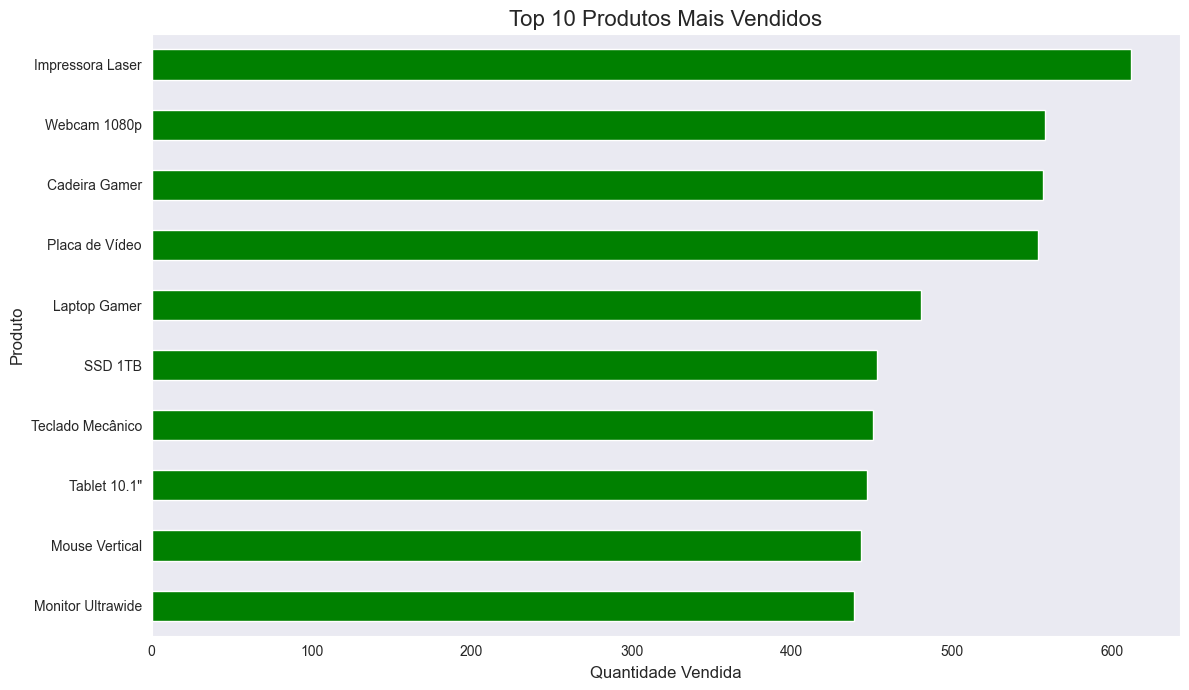

In [40]:
# Define um estilo para os gráficos
sns.set_style("dark")

# Cria a figura e os eixos
plt.figure(figsize = (12, 7))

# Cria o gráfico de barras horizontais
top_10.sort_values(ascending = True).plot(kind = 'barh', color = 'green')

# Adiciona títulos e labels
plt.title('Top 10 Produtos Mais Vendidos', fontsize = 16)
plt.xlabel('Quantidade Vendida', fontsize = 12)
plt.ylabel('Produto', fontsize = 12)

# Exibe o gráfico
plt.tight_layout()
plt.show()

## 7. Análise 2 - Faturamento Mensal

Qual foi o faturamento mensal?

In [41]:
df_vendas.head()

,id,id_client,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,Cidade,Estado,Faturamento,Status_Entrega
0,100,1,2025-01-01 14:00:00,Monitor Ultrawide,Eletrônicos,2594.62,2,Fortaleza,CE,5189.24,Normal
1,101,36,2025-01-01 10:00:00,Teclado Mecânico,Acessórios,550.00,7,Salvador,BA,3850.00,Normal
2,102,92,2025-01-01 12:00:00,Placa de Vídeo,Hardware,4500.00,3,Porto Alegre,RS,13500.00,Normal
3,103,34,2025-01-01 07:00:00,Headset 7.1,Acessórios,800.00,6,Belém,PA,4800.00,Normal
4,104,12,2025-01-01 13:00:00,Laptop Gamer,Eletrônicos,7500.00,2,Manaus,AM,15000.00,Normal


In [42]:
# Cria uma coluna 'Mês' para facilitar o agrupamento mensal
df_vendas['Mês'] = df_vendas['Data_Pedido'].dt.to_period('M')

In [43]:
df_vendas.head()

,id,id_client,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,Cidade,Estado,Faturamento,Status_Entrega,Mês
0,100,1,2025-01-01 14:00:00,Monitor Ultrawide,Eletrônicos,2594.62,2,Fortaleza,CE,5189.24,Normal,2025-01
1,101,36,2025-01-01 10:00:00,Teclado Mecânico,Acessórios,550.00,7,Salvador,BA,3850.00,Normal,2025-01
2,102,92,2025-01-01 12:00:00,Placa de Vídeo,Hardware,4500.00,3,Porto Alegre,RS,13500.00,Normal,2025-01
3,103,34,2025-01-01 07:00:00,Headset 7.1,Acessórios,800.00,6,Belém,PA,4800.00,Normal,2025-01
4,104,12,2025-01-01 13:00:00,Laptop Gamer,Eletrônicos,7500.00,2,Manaus,AM,15000.00,Normal,2025-01


In [52]:
# Agrupa por mês e soma o faturamento total
faturamento_monthly = df_vendas.groupby('Mês')['Faturamento'].sum()

In [53]:
# Convertendo o índice para string para facilitar a plotagem no gráfico
faturamento_monthly.index = faturamento_monthly.index.strftime('%Y-%m')

In [54]:
# Formata o valor da soma em duas casas decimais
faturamento_monthly.map('R$ {:,.2f}'.format)

Mês
2025-01    R$ 1,825,807.69
2025-02    R$ 1,672,283.55
2025-03    R$ 1,331,167.80
2025-04    R$ 1,665,616.68
2025-05    R$ 1,750,190.51
2025-06    R$ 1,684,823.19
2025-07    R$ 1,046,187.89
Name: Faturamento, dtype: object

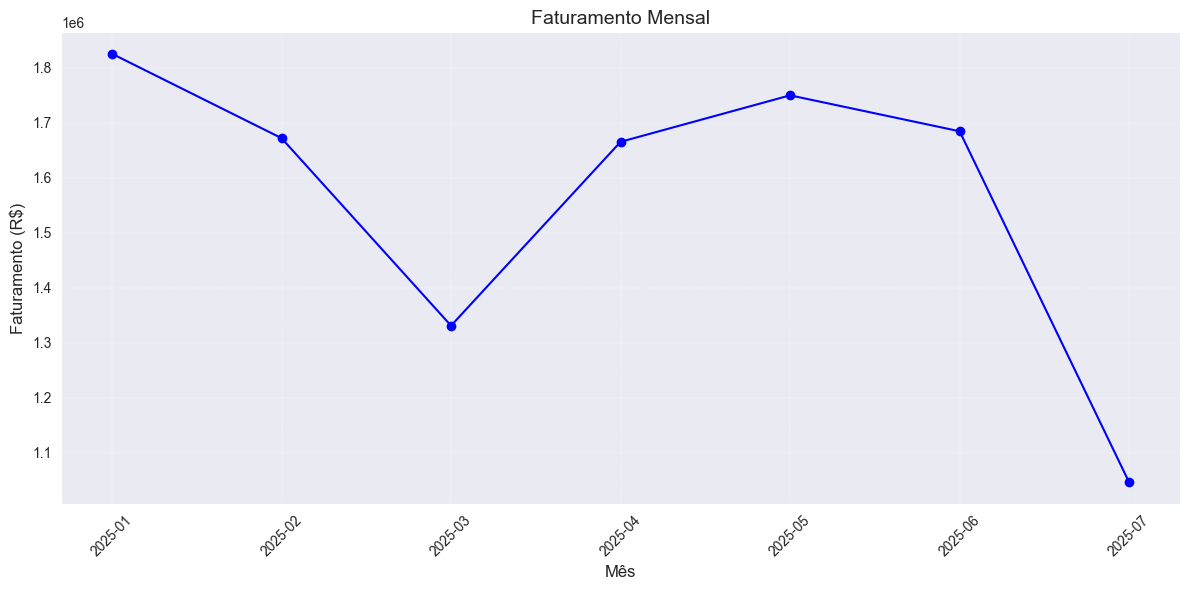

In [56]:
# Cria uma nova figura para o gráfico com tamanho de 12 por 6 polegadas
plt.figure(figsize = (12, 6))

# Plotando os dados de faturamento mensal em formato de gráfico de linha
faturamento_monthly.plot(kind = 'line', marker = 'o', linestyle = '-', color = 'blue')

# Defiindoe o título do gráfico com fonte de tamanho 16
plt.title('Faturamento Mensal', fontsize = 14)

# Define o rótulo do eixo X
plt.xlabel('Mês', fontsize = 12)

# Define o rótulo do eixo Y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# Rotacionando os valores do eixo X em 45 graus para melhor visualização
plt.xticks(rotation = 45)

# Adicionando uma grade com estilo tracejado e linhas finas
plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.25)

# Ajustando automaticamente os elementos para evitar sobreposição
plt.tight_layout()

# Exibindo o gráfico
plt.show()

## 8. Análise 3 - Vendas Por Estado

Qual o total de vendas por estado?

In [58]:
# Agrupando por estado e soma o faturamento total por UF
vendas_estado = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending = False)

In [59]:
# Formatando para duas casas decimais a soma todal
vendas_estado.map('R$ {:,.2f}'.format)

Estado
SP    R$ 1,059,109.40
RS      R$ 967,364.99
DF      R$ 938,057.05
PR      R$ 907,278.59
RJ      R$ 870,331.61
BA      R$ 846,001.54
MG      R$ 845,145.61
CE      R$ 827,537.51
GO      R$ 796,903.28
SC      R$ 763,159.00
AM      R$ 762,819.82
PE      R$ 725,965.58
PA      R$ 666,403.33
Name: Faturamento, dtype: object

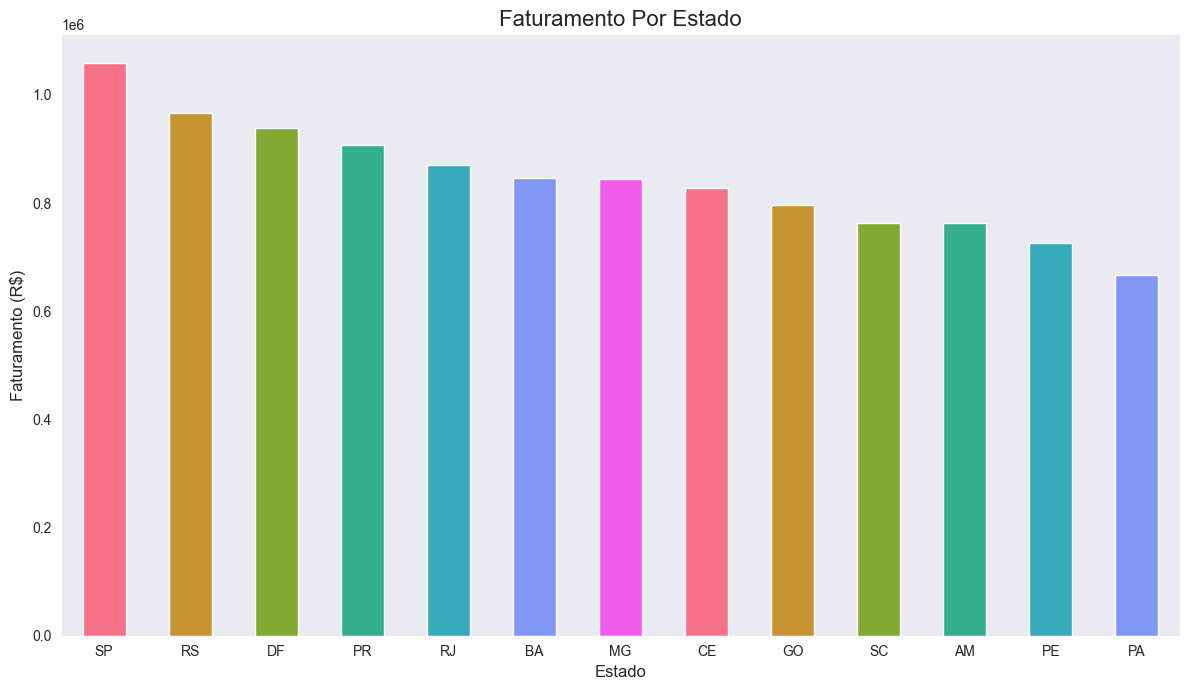

In [60]:
# Criando uma nova figura com tamanho de 12 por 7 polegadas
plt.figure(figsize = (12, 7))

# Plotando os dados de faturamento por estado em formato de gráfico de barras
vendas_estado.plot(kind = 'bar', color = sns.color_palette("husl", 7))

# Definindo o título do gráfico com fonte de tamanho 16
plt.title('Faturamento Por Estado', fontsize = 16)

# Definindo o rótulo do eixo X
plt.xlabel('Estado', fontsize = 12)

# Definindo o rótulo do eixo Y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# Mantendo os rótulos do eixo X na horizontal (sem rotação)
plt.xticks(rotation = 0)

# Ajustando automaticamente os elementos do gráfico para evitar sobreposição
plt.tight_layout()

# Exibindo o gráfico
plt.show()

## 9. Análise 4 - Faturamento Por Categoria

Qual o faturamento total por categoria?

In [62]:
# Agrupando por categoria, soma o faturamento e formata como moeda para melhor leitura
faturamento_categoria = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False)

In [63]:
# O .map('{:,.2f}'.format) é opcional, mas deixa a visualização mais simples e objetiva
faturamento_categoria.map('R$ {:,.2f}'.format)

Categoria
Eletrônicos    R$ 5,762,427.87
Hardware       R$ 2,764,800.00
Impressão        R$ 918,000.00
Acessórios       R$ 897,300.00
Móveis           R$ 633,549.44
Name: Faturamento, dtype: object

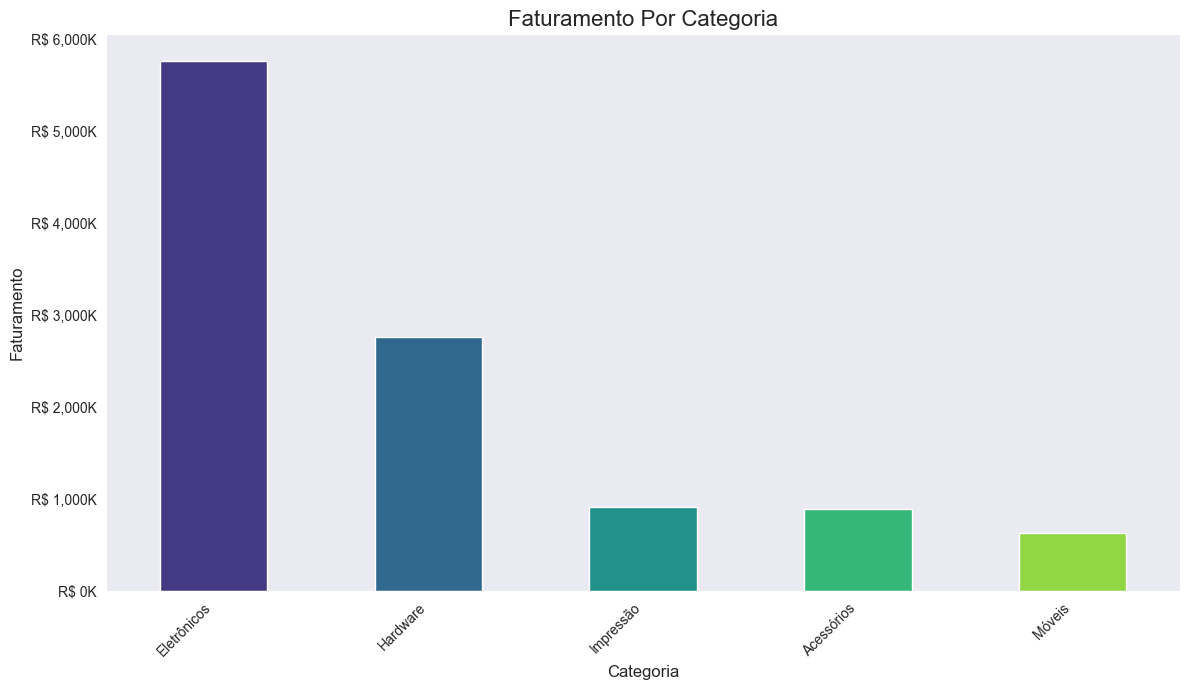

In [64]:
# Importando a função FuncFormatter para formatar os eixos
from matplotlib.ticker import FuncFormatter

# Ordenando os dados para o gráfico mais simples em questão de leitura
faturamento_ordenado = faturamento_categoria.sort_values(ascending = False)

# Criando a Figura e os Eixos (ax) com plt.subplots()
# Isso nos dá mais controle sobre os elementos do gráfico.
fig, ax = plt.subplots(figsize = (12, 7))

# Criando uma função para formatar os números
# Esta função recebe um valor 'y' e o transforma em uma string no formato 'R$ XX K'
def formatador_milhares(y, pos):
    """Formata o valor em milhares (K) com o cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

# Criando o objeto formatador
formatter = FuncFormatter(formatador_milhares)

# Aplicando o formatador ao eixo Y (ax.yaxis)
ax.yaxis.set_major_formatter(formatter)

# Plotando os dados usando o objeto 'ax'
faturamento_ordenado.plot(kind = 'bar', ax = ax, color = sns.color_palette("viridis", len(faturamento_ordenado)))

# Adicionando títulos e labels usando 'ax.set_...'
ax.set_title('Faturamento Por Categoria', fontsize = 16)
ax.set_xlabel('Categoria', fontsize = 12)
ax.set_ylabel('Faturamento', fontsize = 12)

# Ajustando a rotação dos rótulos do eixo X
plt.xticks(rotation = 45, ha = 'right')

# Garantindo que tudo fique bem ajustado na imagem final
plt.tight_layout()

# Exibindo o gráfico
plt.show()